Part A

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib . pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

Part B

In [2]:
df = sns.load_dataset('titanic')
print(df.shape)
(df.head())

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


survived is our column to be predicted, so it will remain ofc
pclass can be useful in prediction as passengers in higher classes had higher chances of survival
sex is also uselful as females had greater survival rates due to emergency boats being reserved mostly for them
age, adult_male, embarked can be an important factor too for the same reasons

fare is dependent of pcalss so it can be redundant if it doesnt provide any useful info about survival, similarly class, who, embark_town, alone are redundant features too as this info is available from previous features
deck has a lot of null values so itll be useless
alive is the same as 'Survivied' feature which is our target so data leakage exisits here

Part C

C:\Users\Muhammad Ibrahim\AppData\Local\Temp\ipykernel_34592\2218362461.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_rate = df.groupby(col)['survived'].mean().sort_values()
C:\Users\Muhammad Ibrahim\AppData\Local\Temp\ipykernel_34592\2218362461.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_rate = df.groupby(col)['survived'].mean().sort_values()


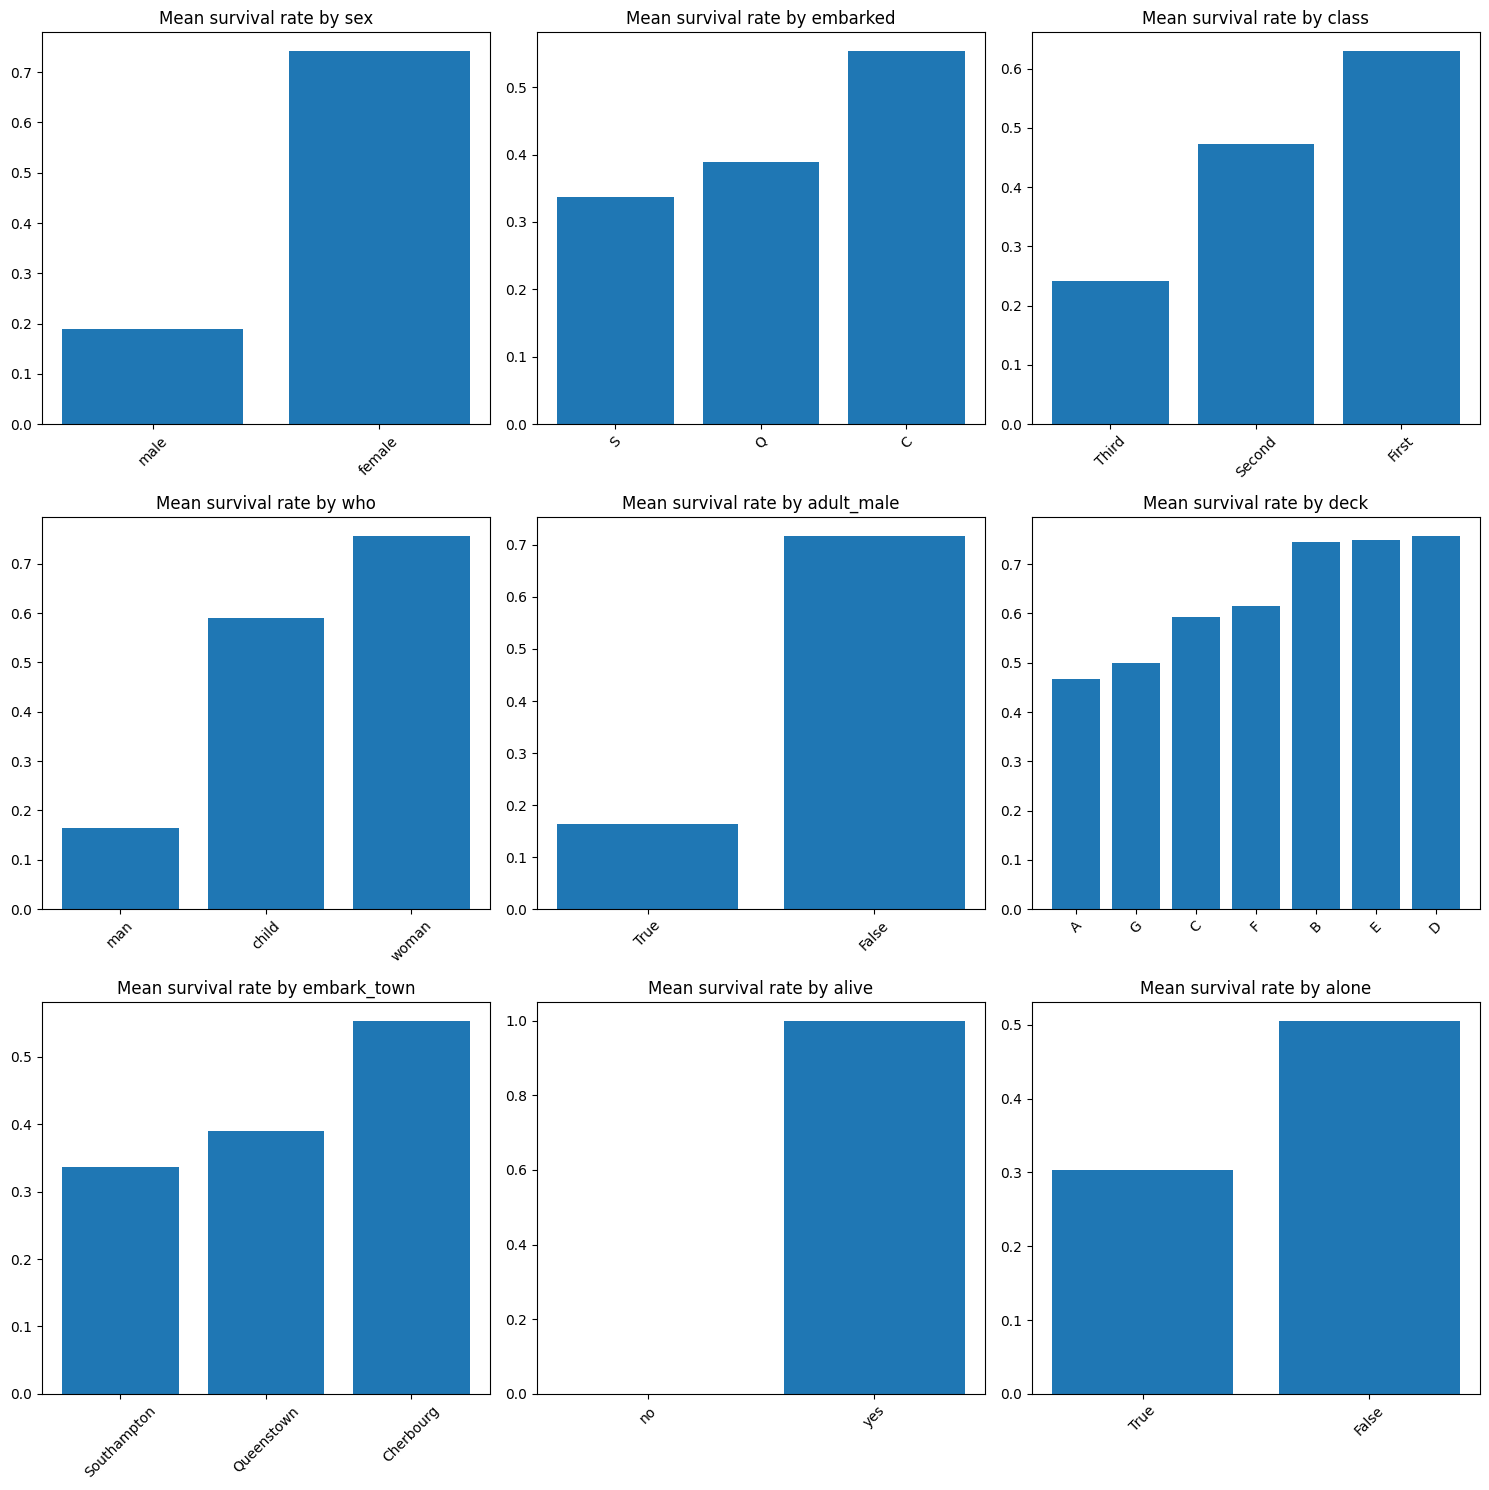

In [3]:
cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns
n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)
plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cat_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    survival_rate = df.groupby(col)['survived'].mean().sort_values()
    plt.bar(survival_rate.index.astype(str), survival_rate.values)
    plt.title(f'Mean survival rate by {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [4]:
drop_cols = ['alive', 'who', 'adult_male', 'embark_town', 'class', 'deck', 'alone']
df = df.drop(columns=drop_cols)

y = df['survived']
X = df.drop(columns=['survived'])

X['age'] = X['age'].fillna(X['age'].median()) 
X['embarked'] = X['embarked'].fillna(X['embarked'].mode()[0])

X = pd.get_dummies(X, columns=['sex', 'embarked'])

print(X.shape, y.shape) 

(891, 10) (891,)


Part D

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

print("\nClass balance:\n")
print(f"Train set\n survived 0: {(y_train==0).sum()}  \tsurvived 1: {(y_train==1).sum()}  \tratio: {y_train.mean()}")
print(f"\nTest  set\n survived 0: {(y_test==0).sum()}  \tsurvived 1: {(y_test==1).sum()}  \tratio: {y_test.mean()}")
print(f"\nFull   set\n survived 0: {(y==0).sum()}  \tsurvived 1: {(y==1).sum()}  \tratio: {y.mean()}")

X_train: (712, 10)
X_test:  (179, 10)
y_train: (712,)
y_test:  (179,)

Class balance:

Train set
 survived 0: 439  	survived 1: 273  	ratio: 0.38342696629213485

Test  set
 survived 0: 110  	survived 1: 69  	ratio: 0.3854748603351955

Full   set
 survived 0: 549  	survived 1: 342  	ratio: 0.3838383838383838


Part F

In [6]:
class Node:
    def __init__(self, left=None, right=None, feature=None, threshold=None, classifier=None):
        self.left = left
        self.right = right
        self.feature = feature
        self.threshold = threshold
        self.classifier = classifier

    def is_leaf(self):
        return self.classifier is not None


class DecisionTree:
    def __init__(self, max_depth = 5, min_samples_split = 5):
        self.max_depth = max_depth
        self.min_samples = min_samples_split
        self.root = None

    def fit(self, Xy):
        self.root = self._make_tree(Xy, depth=0)

    def predict(self, X):
        results = []
        for row in X:
            node = self.root
            while not node.is_leaf():
                if row[node.feature] <= node.threshold:
                    node = node.left
                else:
                    node = node.right
            results.append(node.classifier)
        return np.array(results)

    def _make_tree(self, Xy, depth):
        y = Xy[:, -1]

        if len(np.unique(y)) == 1:
            return Node(classifier=int(y[0]))

        if len(Xy) < self.min_samples:
            return Node(classifier=self._majority(y))

        if depth >= self.max_depth:
            return Node(classifier=self._majority(y))

        feat, thresh = self._best_split(Xy)

        if feat is None:
            return Node(classifier=self._majority(y))

        left_mask = Xy[:, feat] <= thresh
        right_mask = ~left_mask

        left = self._make_tree(Xy[left_mask],  depth + 1)
        right = self._make_tree(Xy[right_mask], depth + 1)

        return Node(left=left, right=right, feature=feat, threshold=thresh)

    def _best_split(self, Xy):
        best_gain = -1
        best_feat = None
        best_thresh = None

        parent_H = self._gini_of_data(Xy)
        n_features = Xy.shape[1] - 1 

        for f in range(n_features):
            thresholds = np.unique(Xy[:, f]) 

            for thresh in thresholds:
                left  = Xy[Xy[:, f] <= thresh]
                right = Xy[Xy[:, f] >  thresh]

                if len(left) == 0 or len(right) == 0:
                    continue

                gain = self._information_gain(parent_H, left, right)

                if gain > best_gain:
                    best_gain   = gain
                    best_feat   = f
                    best_thresh = thresh

        return best_feat, best_thresh

    def _gini_of_data(self, Xy):
        y = Xy[:, -1]
        n = len(y)
        if n == 0:
            return 0.0
        classes, counts = np.unique(y, return_counts=True)
        probs = counts / n
        return 1.0 - np.sum(probs ** 2)

    def _information_gain(self, parent_H, left, right):
        n = len(left) + len(right)
        w_left = len(left)  / n
        w_right = len(right) / n
        child_H = w_left * self._gini_of_data(left) + w_right * self._gini_of_data(right)
        return parent_H - child_H

    @staticmethod
    def _majority(y):
        vals, counts = np.unique(y, return_counts=True)
        return int(vals[np.argmax(counts)])

Part G

Accuracy : 0.7653631284916201
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.88      0.82       110
           1       0.75      0.58      0.66        69

    accuracy                           0.77       179
   macro avg       0.76      0.73      0.74       179
weighted avg       0.76      0.77      0.76       179

Confusion Matrix:
 [[97 13]
 [29 40]]


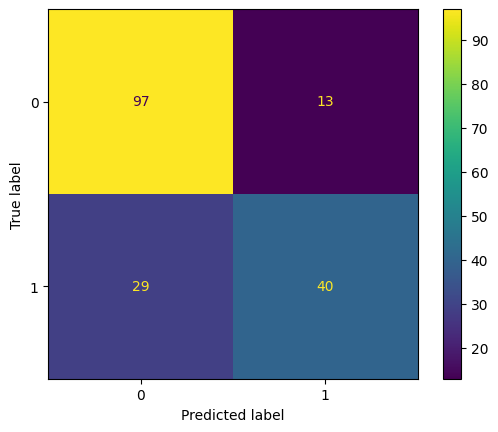

In [12]:
Xy_train = np.c_[X_train.values, y_train.values]
dt = DecisionTree(max_depth=5, min_samples_split=5)
dt.fit(Xy_train)
y_pred = dt.predict(X_test.values)

accuracy = accuracy_score(y_test, y_pred)
classif_rep = classification_report(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy :", accuracy)
print("Classification Report:\n", classif_rep)
print("Confusion Matrix:\n", cm)
ConfusionMatrixDisplay(cm).plot()
plt.show()

The model achieves an accuracy of around 76 to 77% indicating good overall performance.
Precision shows that when the model predicts a passenger survived it is correct most of the time. However recall is comparatively lower meaning the model fails to identify a portion of actual survivors.

Assuming the Accuracy is stuck at 60% accuracy, the most probable reason is underfitting due to limited depth or unoptimized code leading to incorrect feature selection in tree, or it can be due to invalid feature selection during preprocessing stage (often caused by removing important features from dataset).

Part H

Depth: 1, Accuracy: 0.7765
Depth: 2, Accuracy: 0.7598
Depth: 3, Accuracy: 0.7933
Depth: 4, Accuracy: 0.7877
Depth: 5, Accuracy: 0.7654
Depth: 6, Accuracy: 0.7821
Depth: 7, Accuracy: 0.7933
Depth: 8, Accuracy: 0.8045
Depth: 9, Accuracy: 0.8101
Depth: 10, Accuracy: 0.7989
Depth: 11, Accuracy: 0.7877
Depth: 12, Accuracy: 0.7933
Depth: 13, Accuracy: 0.7933
Depth: 14, Accuracy: 0.7933
Depth: 15, Accuracy: 0.7989


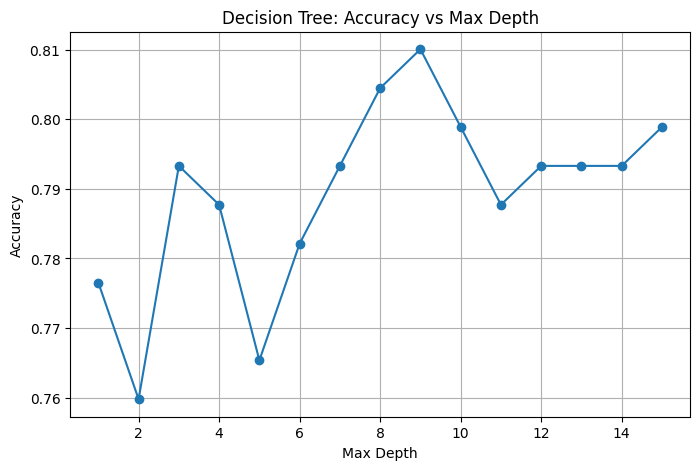

Best Depth: 9
Best Accuracy: 0.8100558659217877


In [14]:
depths = list(range(1, 16))   # try depths 1 to 15
accuracies = []

for d in depths:
    dt = DecisionTree(max_depth=d, min_samples_split=5)
    dt.fit(Xy_train)
    y_pred = dt.predict(X_test.values)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"Depth: {d}, Accuracy: {acc:.4f}")

plt.figure(figsize=(8,5))
plt.plot(depths, accuracies, marker='o')
plt.title("Decision Tree: Accuracy vs Max Depth")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

best = np.argmax(accuracies)
best_depth = depths[best]
best_acc = accuracies[best]

print("Best Depth:", best_depth)
print("Best Accuracy:", best_acc)

As the depth increases the accuracy improves in start because the tree becomes more capable of capturing complex patterns in the data but after a certain depth, the accuracy doesnt change or slightly decreases due to overfitting, where the model starts memorizing noise in the training data instead of learning general patterns.